Generating synthetic credit risk dataset...
Dataset shape: (10000, 12)
Default rate: 18.74%

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      10000 non-null  int32  
 1   income                   10000 non-null  int64  
 2   employment_length        10000 non-null  int64  
 3   credit_score             10000 non-null  int64  
 4   debt_to_income           10000 non-null  float64
 5   loan_amount              10000 non-null  float64
 6   loan_term                10000 non-null  int64  
 7   number_of_open_accounts  10000 non-null  int32  
 8   number_of_delinquencies  10000 non-null  int32  
 9   housing                  10000 non-null  object 
 10  purpose                  10000 non-null  object 
 11  default                  10000 non-null  int64  
dtypes: float64(2), int32(3),

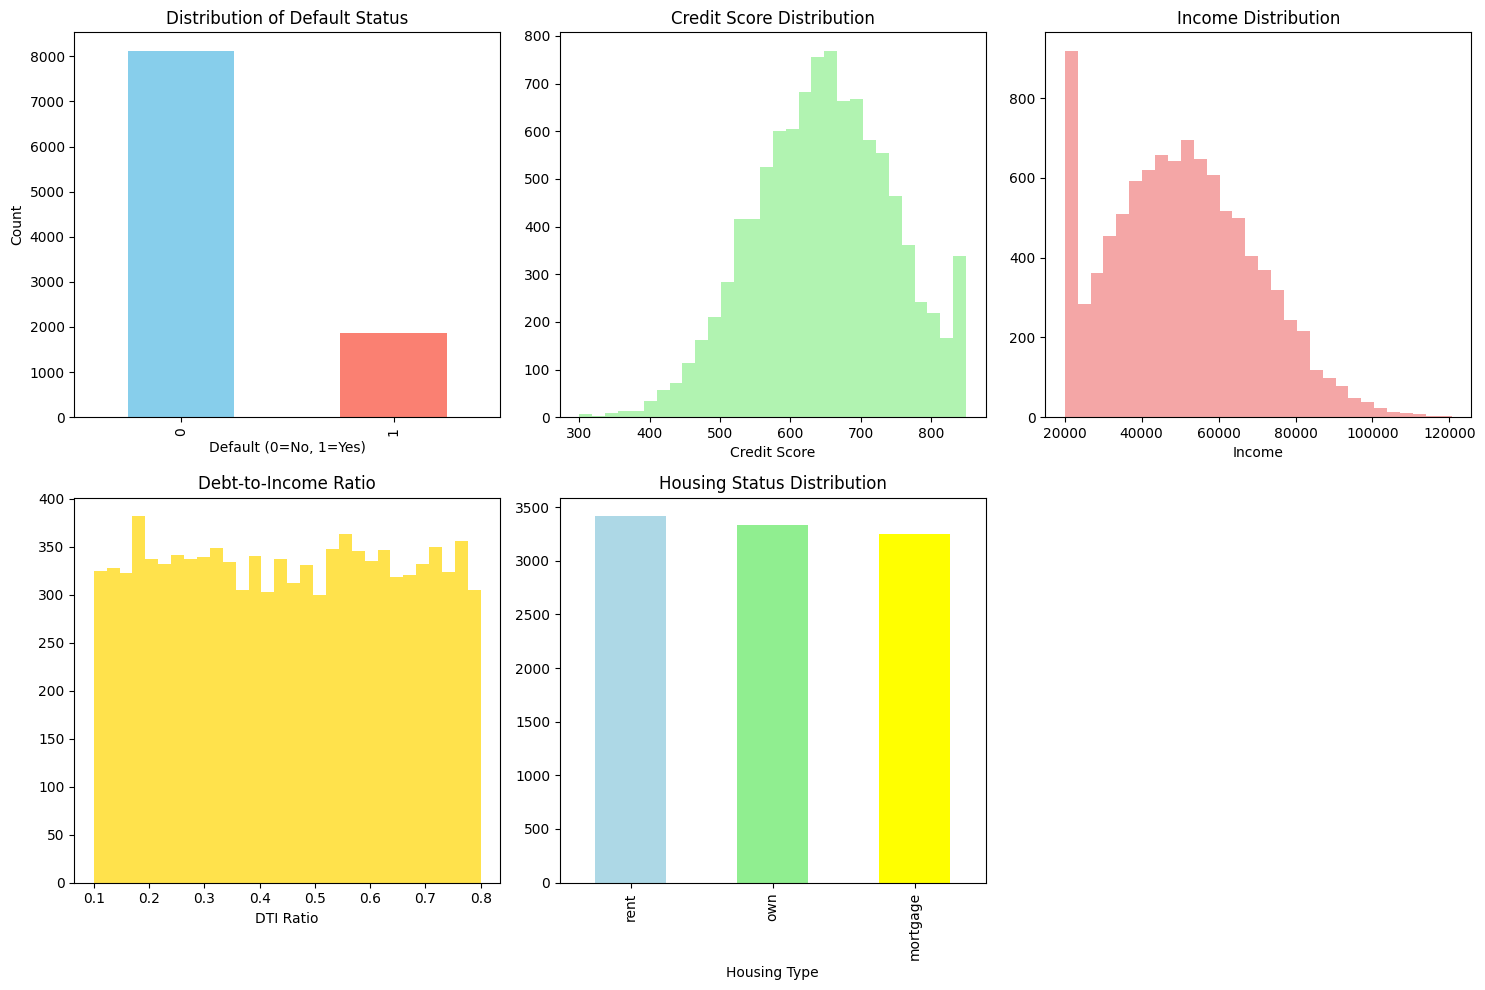

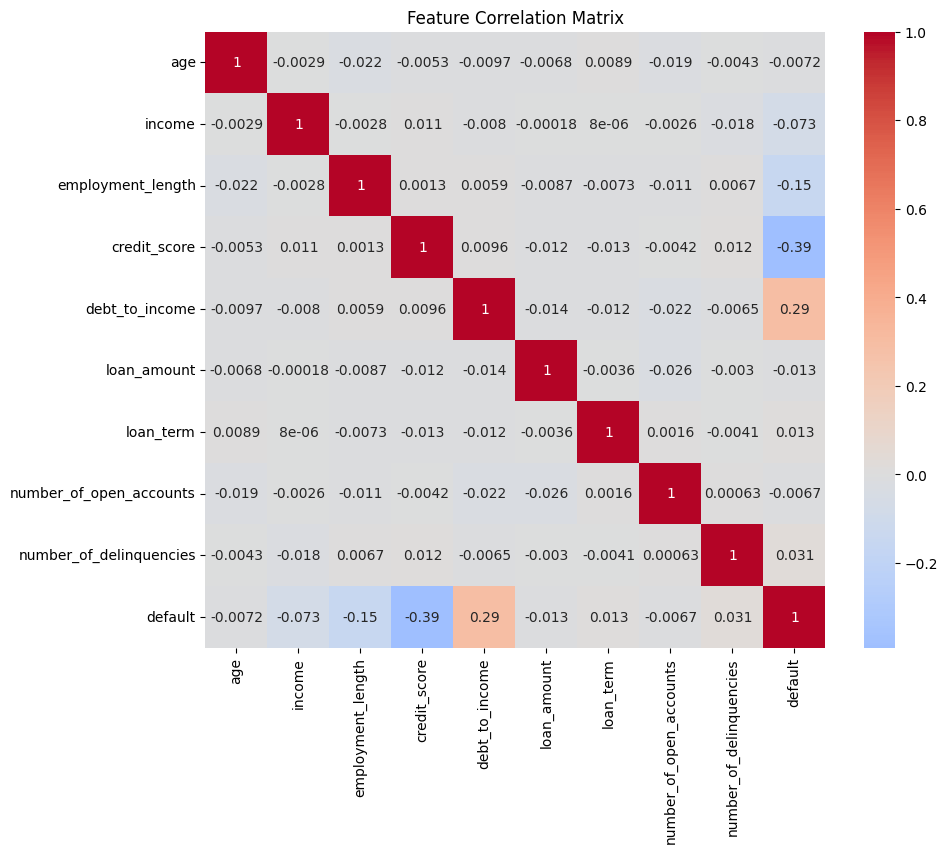


DATA PREPROCESSING
Training set size: (8000, 11)
Test set size: (2000, 11)
Training default rate: 18.74%
Test default rate: 18.75%

MODEL TRAINING
Training Random Forest model...
Cross-validation ROC-AUC scores: [0.95829552 0.95257436 0.96186667 0.95319231 0.95808718]
Mean CV ROC-AUC: 0.9568 (+/- 0.0070)

MODEL EVALUATION
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1625
           1       0.76      0.70      0.73       375

    accuracy                           0.90      2000
   macro avg       0.85      0.82      0.84      2000
weighted avg       0.90      0.90      0.90      2000

Confusion Matrix:
[[1544   81]
 [ 113  262]]
ROC-AUC Score: 0.9543


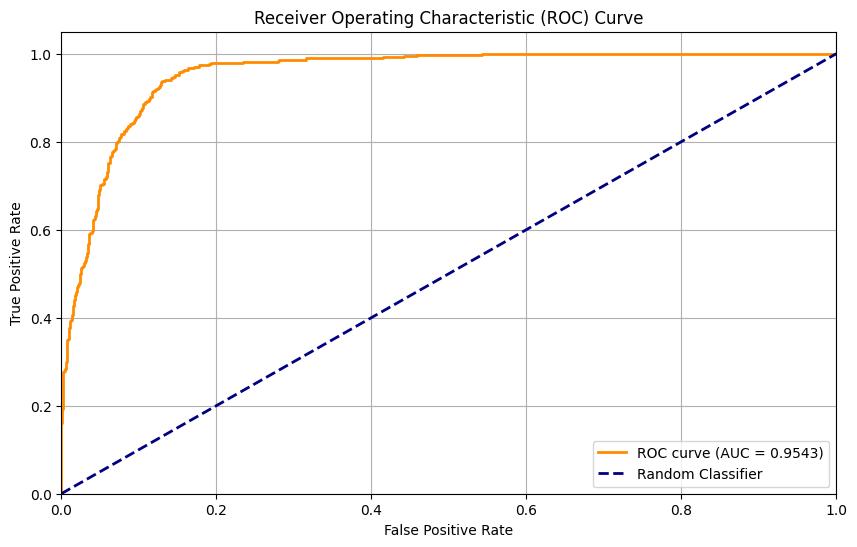


FEATURE IMPORTANCE
Top 10 Most Important Features:
                    feature  importance
3              credit_score    0.429885
4            debt_to_income    0.252277
2         employment_length    0.137941
1                    income    0.053672
5               loan_amount    0.033049
0                       age    0.027314
7   number_of_open_accounts    0.023231
10                  purpose    0.013204
8   number_of_delinquencies    0.011528
6                 loan_term    0.010781


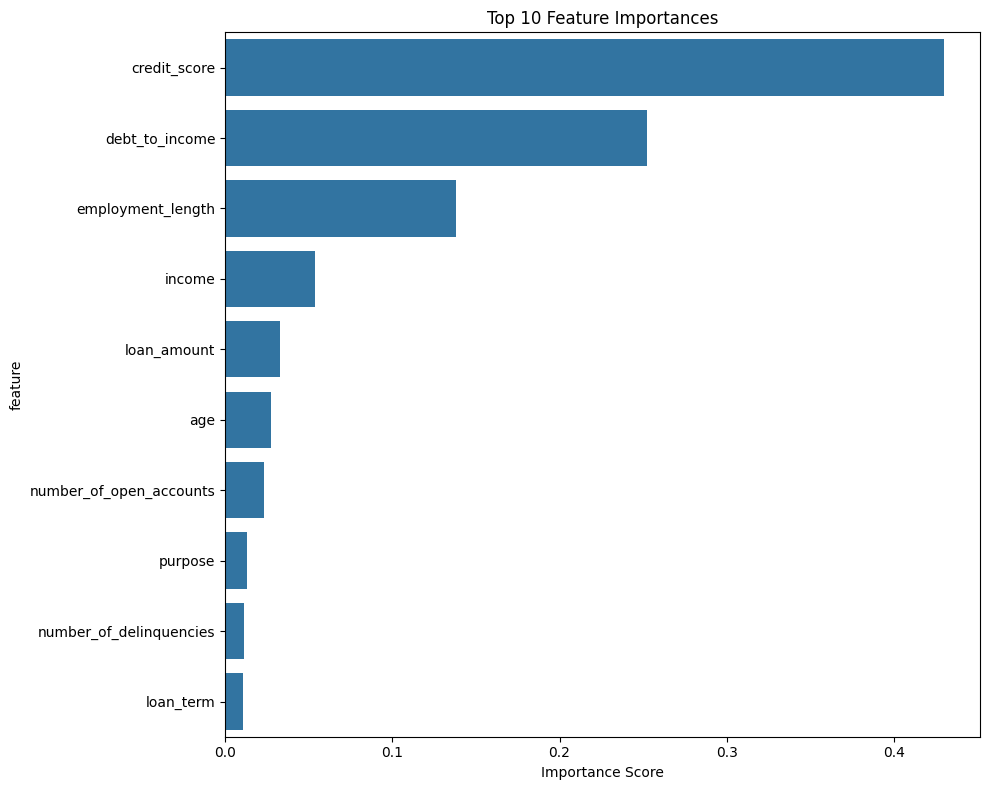


HYPERPARAMETER TUNING (Optional)

PREDICTION ON NEW DATA
New Applicant Details:
  age: 35
  income: 55000
  employment_length: 5
  credit_score: 720
  debt_to_income: 0.35
  loan_amount: 25000
  loan_term: 36
  number_of_open_accounts: 8
  number_of_delinquencies: 0
  housing: mortgage
  purpose: debt_consolidation

Default Probability: 0.05%
Risk Category: Low Risk
Credit Risk Score: 999/1000

MODEL INTERPRETATION
Key Insights:
1. Features like credit score, debt-to-income ratio, and employment history
   are typically strong predictors of credit risk.
2. The model provides probability scores that can be used for risk-based pricing.
3. Feature importance analysis helps in understanding what drives credit decisions.

Model artifacts saved to 'credit_risk_model.pkl'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic credit risk dataset
def generate_credit_data(n_samples=10000):
    """Generate synthetic credit risk data for demonstration"""
    np.random.seed(42)
    
    data = {
        'age': np.random.randint(18, 70, n_samples),
        'income': np.random.normal(50000, 20000, n_samples).astype(int),
        'employment_length': np.random.exponential(5, n_samples).astype(int),
        'credit_score': np.random.normal(650, 100, n_samples).astype(int),
        'debt_to_income': np.random.uniform(0.1, 0.8, n_samples),
        'loan_amount': np.random.uniform(1000, 100000, n_samples),
        'loan_term': np.random.choice([12, 24, 36, 48, 60], n_samples),
        'number_of_open_accounts': np.random.randint(1, 20, n_samples),
        'number_of_delinquencies': np.random.poisson(0.5, n_samples),
        'housing': np.random.choice(['rent', 'mortgage', 'own'], n_samples),
        'purpose': np.random.choice(['debt_consolidation', 'credit_card', 'home_improvement', 
                                   'medical', 'car', 'other'], n_samples)
    }
    
    df = pd.DataFrame(data)
    
    # Ensure reasonable ranges
    df['income'] = df['income'].clip(20000, 150000)
    df['credit_score'] = df['credit_score'].clip(300, 850)
    df['employment_length'] = df['employment_length'].clip(0, 40)
    
    # Create target variable based on features (with some noise)
    default_prob = (
        (df['credit_score'] < 600) * 0.3 +
        (df['debt_to_income'] > 0.5) * 0.25 +
        (df['employment_length'] < 2) * 0.2 +
        (df['number_of_delinquencies'] > 2) * 0.15 +
        (df['income'] < 30000) * 0.1 +
        np.random.normal(0, 0.1, n_samples)
    )
    
    df['default'] = (default_prob > 0.5).astype(int)
    
    return df

# Generate dataset
print("Generating synthetic credit risk dataset...")
df = generate_credit_data(10000)
print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df['default'].mean():.2%}")

# Display basic info
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Exploratory Data Analysis
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# Distribution of target variable
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
df['default'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Count')

# Numerical features distribution
plt.subplot(2, 3, 2)
plt.hist(df['credit_score'], bins=30, alpha=0.7, color='lightgreen')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')

plt.subplot(2, 3, 3)
plt.hist(df['income'], bins=30, alpha=0.7, color='lightcoral')
plt.title('Income Distribution')
plt.xlabel('Income')

plt.subplot(2, 3, 4)
plt.hist(df['debt_to_income'], bins=30, alpha=0.7, color='gold')
plt.title('Debt-to-Income Ratio')
plt.xlabel('DTI Ratio')

plt.subplot(2, 3, 5)
df['housing'].value_counts().plot(kind='bar', color=['lightblue', 'lightgreen', 'yellow'])
plt.title('Housing Status Distribution')
plt.xlabel('Housing Type')

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# Data Preprocessing
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Separate features and target
X = df.drop('default', axis=1)
y = df['default']

# Handle categorical variables
categorical_cols = ['housing', 'purpose']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['age', 'income', 'employment_length', 'credit_score', 
                  'debt_to_income', 'loan_amount', 'loan_term',
                  'number_of_open_accounts', 'number_of_delinquencies']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Model Training
print("\n" + "="*50)
print("MODEL TRAINING")
print("="*50)

# Initialize Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_train_scaled, y_train)

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Cross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Model Evaluation
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(10, 6))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Feature Importance
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning (Optional - can be slow)
print("\n" + "="*50)
print("HYPERPARAMETER TUNING (Optional)")
print("="*50)

# Uncomment below for hyperparameter tuning
"""
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Performing hyperparameter tuning...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use best model
best_rf_model = grid_search.best_estimator_
"""

# Prediction on new data
print("\n" + "="*50)
print("PREDICTION ON NEW DATA")
print("="*50)

# Create a sample new applicant
new_applicant = pd.DataFrame({
    'age': [35],
    'income': [55000],
    'employment_length': [5],
    'credit_score': [720],
    'debt_to_income': [0.35],
    'loan_amount': [25000],
    'loan_term': [36],
    'number_of_open_accounts': [8],
    'number_of_delinquencies': [0],
    'housing': ['mortgage'],
    'purpose': ['debt_consolidation']
})

# Preprocess the new applicant
new_applicant_processed = new_applicant.copy()
for col in categorical_cols:
    if col in new_applicant_processed.columns:
        new_applicant_processed[col] = label_encoders[col].transform(new_applicant_processed[col])

new_applicant_processed[numerical_cols] = scaler.transform(new_applicant_processed[numerical_cols])

# Make prediction
default_probability = rf_model.predict_proba(new_applicant_processed)[0, 1]
risk_category = "High Risk" if default_probability > 0.5 else "Low Risk"

print(f"New Applicant Details:")
for col, value in new_applicant.iloc[0].items():
    print(f"  {col}: {value}")
print(f"\nDefault Probability: {default_probability:.2%}")
print(f"Risk Category: {risk_category}")

# Risk score (1 - probability of default, scaled to 0-1000)
risk_score = int((1 - default_probability) * 1000)
print(f"Credit Risk Score: {risk_score}/1000")

# Model Interpretation
print("\n" + "="*50)
print("MODEL INTERPRETATION")
print("="*50)

print("Key Insights:")
print("1. Features like credit score, debt-to-income ratio, and employment history")
print("   are typically strong predictors of credit risk.")
print("2. The model provides probability scores that can be used for risk-based pricing.")
print("3. Feature importance analysis helps in understanding what drives credit decisions.")

# Save the model (optional)
import joblib

model_artifacts = {
    'model': rf_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': X.columns.tolist()
}

joblib.dump(model_artifacts, 'credit_risk_model.pkl')
print("\nModel artifacts saved to 'credit_risk_model.pkl'")